# Read Data & EDA

In [54]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [55]:
data_train = pd.read_csv('train.csv')

In [56]:
data_test = pd.read_csv('test.csv')

In [57]:
data_train.head()

,image_name,label
0,personA_37.png,forged
1,personA_3.png,forged
2,personA_28.png,forged
3,personA_31.png,forged
4,personA_48.png,forged


In [58]:
data_test.head()

,image_name,label
0,personA_2.png,forged
1,personA_42.png,forged
2,personA_33.png,forged
3,personA_20.png,forged
4,personA_29.png,real


In [59]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_name  200 non-null    object
 1   label       200 non-null    object
dtypes: object(2)
memory usage: 3.3+ KB


In [60]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_name  40 non-null     object
 1   label       40 non-null     object
dtypes: object(2)
memory usage: 772.0+ bytes


In [61]:
data_train.duplicated().sum()

np.int64(0)

In [62]:
data_test.duplicated().sum()

np.int64(0)

In [63]:
data_train.describe()

,image_name,label
count,200,200
unique,200,2
top,personA_37.png,forged
freq,1,100


In [64]:
data_test.describe()

,image_name,label
count,40,40
unique,40,2
top,personA_2.png,forged
freq,1,20


In [65]:
data_train.columns

Index(['image_name', 'label'], dtype='object')

In [66]:
data_test.columns

Index(['image_name', 'label'], dtype='object')

# Handel read pictures from folders

In [18]:
r'D:\BFCAI Level 3 T2\AI\Neural Networks\Project\Fake signature\Fake signature\Train'

'D:\\BFCAI Level 3 T2\\AI\\Neural Networks\\Project\\Fake signature\\Fake signature\\Train'

In [19]:
import os

train_dir = r'D:\BFCAI Level 3 T2\AI\Neural Networks\Project\Fake signature\Fake signature\Train'

data_train['image_path'] = data_train['image_name'].apply(lambda x: os.path.join(train_dir, x))

In [20]:
test_dir = r'D:\BFCAI Level 3 T2\AI\Neural Networks\Project\Fake signature\Fake signature\Test'

data_test['image_path'] = data_test['image_name'].apply(lambda x: os.path.join(test_dir, x))

In [21]:
data_train

,image_name,label,image_path
0,personA_37.png,forged,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...
1,personA_3.png,forged,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...
2,personA_28.png,forged,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...
3,personA_31.png,forged,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...
4,personA_48.png,forged,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...
...,...,...,...
195,personE_38.png,real,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...
196,personE_3.png,real,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...
197,personE_19.png,real,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...
198,personE_37.png,real,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...


In [22]:
data_test

,image_name,label,image_path
0,personA_2.png,forged,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...
1,personA_42.png,forged,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...
2,personA_33.png,forged,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...
3,personA_20.png,forged,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...
4,personA_29.png,real,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...
5,personA_13.png,real,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...
6,personA_27.png,real,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...
7,personA_10.png,real,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...
8,personB_2.png,forged,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...
9,personB_42.png,forged,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...


In [23]:
data_train['person'] = data_train['image_name'].apply(lambda x: x.split('_')[0])

In [24]:
import os

train_dir = r'D:\BFCAI Level 3 T2\AI\Neural Networks\Project\Fake signature\Fake signature\Test'

data_train['image_path'] = data_train.apply(
    lambda row: os.path.join(train_dir, row['person'], row['image_name']),
    axis=1
)

In [25]:
data_train

,image_name,label,image_path,person
0,personA_37.png,forged,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...,personA
1,personA_3.png,forged,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...,personA
2,personA_28.png,forged,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...,personA
3,personA_31.png,forged,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...,personA
4,personA_48.png,forged,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...,personA
...,...,...,...,...
195,personE_38.png,real,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...,personE
196,personE_3.png,real,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...,personE
197,personE_19.png,real,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...,personE
198,personE_37.png,real,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...,personE


In [26]:
print(data_train['image_name'].head())

0    personA_37.png
1     personA_3.png
2    personA_28.png
3    personA_31.png
4    personA_48.png
Name: image_name, dtype: object


In [27]:
data_train['image_name'] = data_train['image_name'].str.lower()

# convert categorical to numeric

In [28]:
le = LabelEncoder()
data_train['label'] = le.fit_transform(data_train['label'])
data_test['label'] = le.fit_transform(data_test['label'])

In [29]:
data_train['label'].value_counts()

label
0    100
1    100
Name: count, dtype: int64

In [30]:
data_train

,image_name,label,image_path,person
0,persona_37.png,0,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...,personA
1,persona_3.png,0,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...,personA
2,persona_28.png,0,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...,personA
3,persona_31.png,0,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...,personA
4,persona_48.png,0,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...,personA
...,...,...,...,...
195,persone_38.png,1,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...,personE
196,persone_3.png,1,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...,personE
197,persone_19.png,1,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...,personE
198,persone_37.png,1,D:\BFCAI Level 3 T2\AI\Neural Networks\Project...,personE


# Handel unreading pictures problem

In [31]:
import os

train_dir = r'D:\BFCAI Level 3 T2\AI\Neural Networks\Project\Fake signature\Fake signature\Train'


print("Folder exists:", os.path.exists(train_dir))


print("Files inside:", os.listdir(train_dir))


print("First image name:", data_train['image_name'].iloc[0])


full_path = os.path.join(train_dir, data_train['image_name'].iloc[0])
print("Full path:", full_path)
print("Image exists:", os.path.exists(full_path))

Folder exists: True
Files inside: ['PersonA', 'PersonB', 'PersonC', 'PersonD', 'PersonE']
First image name: persona_37.png
Full path: D:\BFCAI Level 3 T2\AI\Neural Networks\Project\Fake signature\Fake signature\Train\persona_37.png
Image exists: False


In [32]:
import os

train_dir = r'D:\BFCAI Level 3 T2\AI\Neural Networks\Project\Fake signature\Fake signature\Train'


all_files = []
for folder in os.listdir(train_dir):
    folder_path = os.path.join(train_dir, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            all_files.append(f"{folder}/{file}")

print("Example files:", all_files[:5])
print("Total files found:", len(all_files))

Example files: ['PersonA/Copy of personA_1.png', 'PersonA/Copy of personA_11.png', 'PersonA/Copy of personA_12.png', 'PersonA/Copy of personA_14.png', 'PersonA/Copy of personA_15.png']
Total files found: 200


In [33]:
import os

train_dir = r'D:\BFCAI Level 3 T2\AI\Neural Networks\Project\Fake signature\Fake signature\Train'
test_dir  = r'D:\BFCAI Level 3 T2\AI\Neural Networks\Project\Fake signature\Fake signature\Test'


def build_path_map(base_dir):
    path_map = {}
    for folder in os.listdir(base_dir):
        folder_path = os.path.join(base_dir, folder)
        if os.path.isdir(folder_path):
            for file in os.listdir(folder_path):
                
                clean_name = file.replace("Copy of ", "").lower()
                path_map[clean_name] = f"{folder}/{file}"
    return path_map

train_map = build_path_map(train_dir)
test_map  = build_path_map(test_dir)


data_train['image_name'] = data_train['image_name'].str.lower().map(train_map)
data_test['image_name']  = data_test['image_name'].str.lower().map(test_map)


print(data_train['image_name'].head())
print("Train Nulls:", data_train['image_name'].isnull().sum())
print("Test Nulls:",  data_test['image_name'].isnull().sum())

0    PersonA/Copy of personA_37.png
1     PersonA/Copy of personA_3.png
2    PersonA/Copy of personA_28.png
3    PersonA/Copy of personA_31.png
4    PersonA/Copy of personA_48.png
Name: image_name, dtype: object
Train Nulls: 0
Test Nulls: 0


In [34]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


data_train['label'] = data_train['label'].astype(str)
data_test['label']  = data_test['label'].astype(str)

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_dataframe(
    dataframe=data_train,
    directory=train_dir,
    x_col='image_name',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_gen = datagen.flow_from_dataframe(
    dataframe=data_train,
    directory=train_dir,
    x_col='image_name',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

test_gen = datagen.flow_from_dataframe(
    dataframe=data_test,
    directory=test_dir,
    x_col='image_name',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 160 validated image filenames belonging to 2 classes.
Found 40 validated image filenames belonging to 2 classes.
Found 40 validated image filenames belonging to 2 classes.


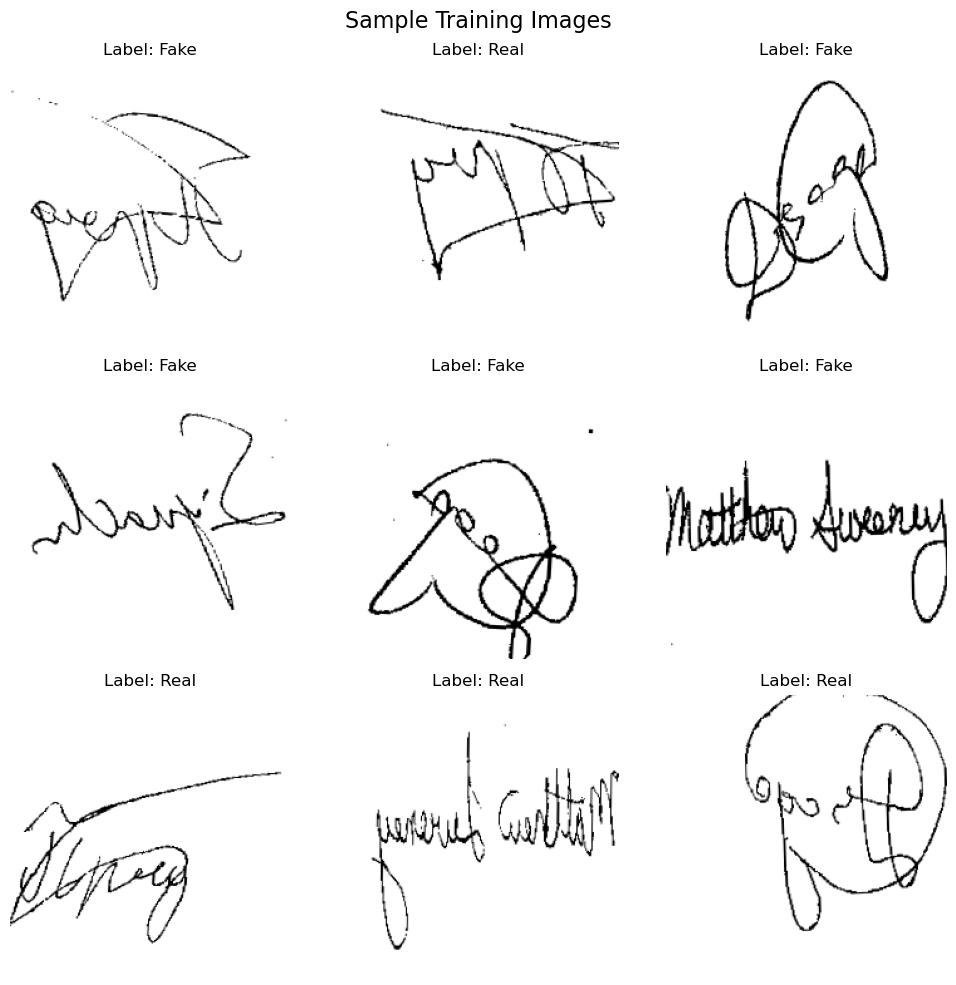

In [67]:
import matplotlib.pyplot as plt
import numpy as np


images, labels = next(train_gen)


plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.title(f"Label: {'Fake' if labels[i] == 1 else 'Real'}")
    plt.axis('off')

plt.suptitle("Sample Training Images", fontsize=16)
plt.tight_layout()
plt.show()

#  Transfer Learning (VGG16) model

In [36]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam


base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)


base_model.trainable = False


x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(1, activation='sigmoid')(x)  

model = Model(inputs=base_model.input, outputs=x)


model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [37]:
# Training

In [38]:
import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', save_best_only=True)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5000 - loss: 0.8488 

5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step - accuracy: 0.5625 - loss: 0.7910 - val_accuracy: 0.5000 - val_loss: 0.7350
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6835 - loss: 0.6034 

5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.6938 - loss: 0.6099 - val_accuracy: 0.5250 - val_loss: 0.5836
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7234 - loss: 0.4542 

5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.7812 - loss: 0.4155 - val_accuracy: 0.6750 - val_loss: 0.5108
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8724 - loss: 0.3535 

5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.9062 - loss: 0.3144 - val_accuracy: 0.8500 - val_loss: 0.4333
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9272 - loss: 0.2601 

5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.9250 - loss: 0.2480 - val_accuracy: 0.9000 - val_loss: 0.3975
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.9563 - loss: 0.1984 - val_accuracy: 0.8500 - val_loss: 0.4131
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9867 - loss: 0.1615 

5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.9750 - loss: 0.1638 - val_accuracy: 0.8750 - val_loss: 0.3666
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9830 - loss: 0.1240 

5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.9750 - loss: 0.1309 - val_accuracy: 0.9000 - val_loss: 0.3585
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.9812 - loss: 0.1223 - val_accuracy: 0.8250 - val_loss: 0.3934
Epoch 10/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.9812 - loss: 0.1010 - val_accuracy: 0.9000 - val_loss: 0.3699


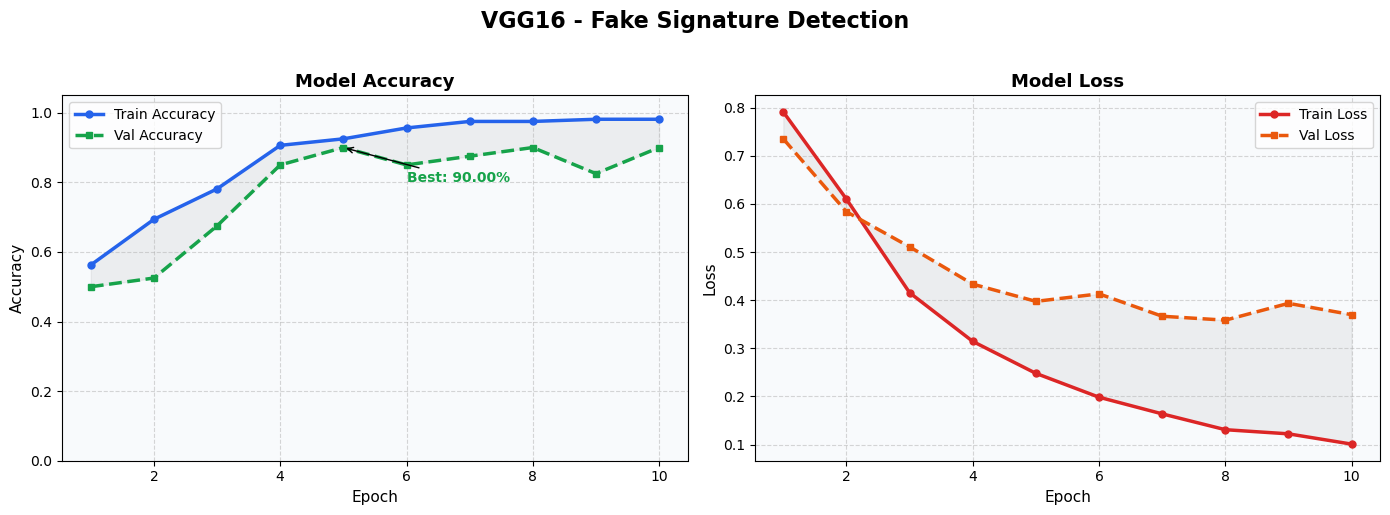

Best Val Accuracy: 90.00% at Epoch 5
Final Train Accuracy: 98.12%
Final Val Accuracy:   90.00%


In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

epochs = range(1, len(history.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('VGG16 - Fake Signature Detection', fontsize=16, fontweight='bold', y=1.02)

# Accuracy plot
axes[0].plot(epochs, history.history['accuracy'], 
             color='#2563EB', linewidth=2.5, marker='o', markersize=5, label='Train Accuracy')
axes[0].plot(epochs, history.history['val_accuracy'], 
             color='#16A34A', linewidth=2.5, marker='s', markersize=5, linestyle='--', label='Val Accuracy')
axes[0].fill_between(epochs, history.history['accuracy'], history.history['val_accuracy'], 
                      alpha=0.1, color='gray')
axes[0].set_title('Model Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_ylim([0, 1.05])
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_facecolor('#F8FAFC')

# Loss plot
axes[1].plot(epochs, history.history['loss'], 
             color='#DC2626', linewidth=2.5, marker='o', markersize=5, label='Train Loss')
axes[1].plot(epochs, history.history['val_loss'], 
             color='#EA580C', linewidth=2.5, marker='s', markersize=5, linestyle='--', label='Val Loss')
axes[1].fill_between(epochs, history.history['loss'], history.history['val_loss'], 
                      alpha=0.1, color='gray')
axes[1].set_title('Model Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_facecolor('#F8FAFC')

# Best accuracy annotation
best_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_acc) + 1
axes[0].annotate(f'Best: {best_acc:.2%}', 
                  xy=(best_epoch, best_acc),
                  xytext=(best_epoch + 1, best_acc - 0.1),
                  arrowprops=dict(arrowstyle='->', color='black'),
                  fontsize=10, color='#16A34A', fontweight='bold')

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best Val Accuracy: {best_acc:.2%} at Epoch {best_epoch}")
print(f"Final Train Accuracy: {history.history['accuracy'][-1]:.2%}")
print(f"Final Val Accuracy:   {history.history['val_accuracy'][-1]:.2%}")

# Fine-tuning (Regularization) to handle OVERFITTING

In [50]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator


datagen_train = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen_val = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen_train.flow_from_dataframe(
    dataframe=data_train,
    directory=train_dir,
    x_col='image_name',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_gen = datagen_val.flow_from_dataframe(
    dataframe=data_train,
    directory=train_dir,
    x_col='image_name',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


for layer in base_model.layers[:-4]:
    layer.trainable = False
for layer in base_model.layers[-4:]:
    layer.trainable = True

x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.6)(x)               
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=x)

model.compile(
    optimizer=Adam(learning_rate=0.00001),  
    loss='binary_crossentropy',
    metrics=['accuracy']
)


callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)

Found 160 validated image filenames belonging to 2 classes.
Found 40 validated image filenames belonging to 2 classes.
Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4954 - loss: 1.1370  

5/5 ━━━━━━━━━━━━━━━━━━━━ 34s 6s/step - accuracy: 0.4875 - loss: 1.1218 - val_accuracy: 0.5000 - val_loss: 0.7341 - learning_rate: 1.0000e-05
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4865 - loss: 1.0089 

5/5 ━━━━━━━━━━━━━━━━━━━━ 29s 6s/step - accuracy: 0.5000 - loss: 0.9498 - val_accuracy: 0.5250 - val_loss: 0.7210 - learning_rate: 1.0000e-05
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 26s 5s/step - accuracy: 0.5688 - loss: 0.9102 - val_accuracy: 0.5250 - val_loss: 0.7091 - learning_rate: 1.0000e-05
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 5s/step - accuracy: 0.5312 - loss: 0.8774 - val_accuracy: 0.5000 - val_loss: 0.6987 - learning_rate: 1.0000e-05
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6233 - loss: 0.7666 

5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 5s/step - accuracy: 0.6062 - loss: 0.8013 - val_accuracy: 0.5750 - val_loss: 0.6903 - learning_rate: 1.0000e-05
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5585 - loss: 0.8411 

5/5 ━━━━━━━━━━━━━━━━━━━━ 28s 6s/step - accuracy: 0.5375 - loss: 0.8749 - val_accuracy: 0.6000 - val_loss: 0.6829 - learning_rate: 1.0000e-05
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 25s 5s/step - accuracy: 0.6000 - loss: 0.8323 - val_accuracy: 0.5250 - val_loss: 0.6794 - learning_rate: 1.0000e-05
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 5s/step - accuracy: 0.6313 - loss: 0.7336 - val_accuracy: 0.5500 - val_loss: 0.6784 - learning_rate: 1.0000e-05
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.6375 - loss: 0.7471 - val_accuracy: 0.5500 - val_loss: 0.6773 - learning_rate: 1.0000e-05
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.6875 - loss: 0.6745 - val_accuracy: 0.5250 - val_loss: 0.6770 - learning_rate: 1.0000e-05
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - accuracy: 0.5813 - loss: 0.8331 - val_accuracy: 0.5500 - val_loss: 0.6771 - learning_rate: 1.0000e-05
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - accuracy: 0.7125 - loss: 0.6864 - val_accuracy

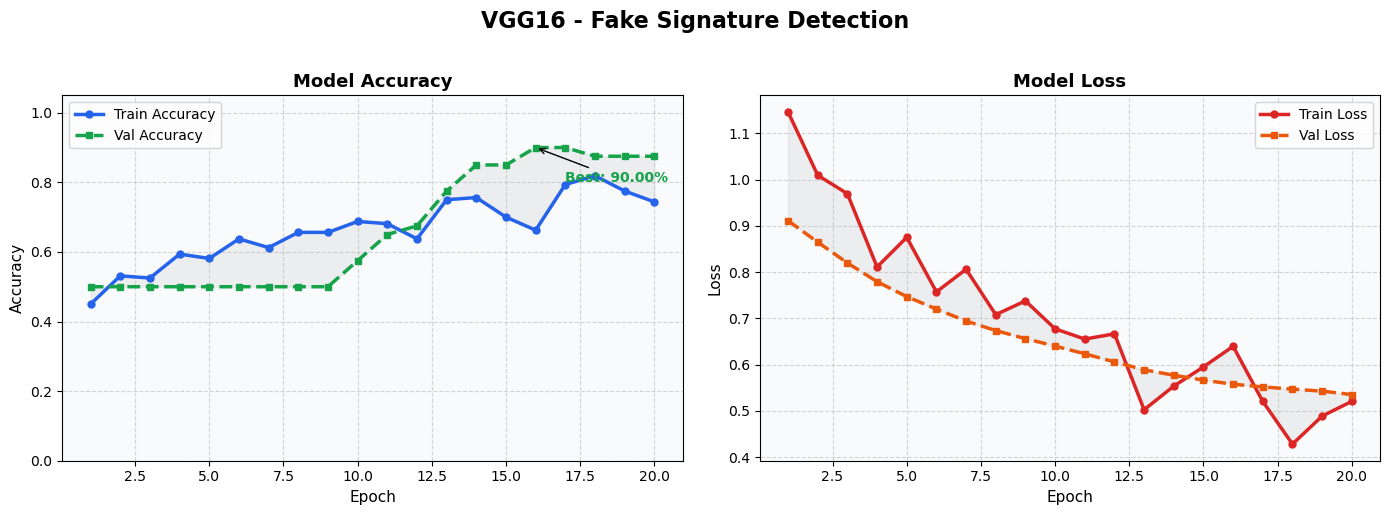

Best Val Accuracy: 90.00% at Epoch 16
Final Train Accuracy: 74.37%
Final Val Accuracy:   87.50%


In [43]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

epochs = range(1, len(history.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('VGG16 - Fake Signature Detection', fontsize=16, fontweight='bold', y=1.02)

# Accuracy plot
axes[0].plot(epochs, history.history['accuracy'], 
             color='#2563EB', linewidth=2.5, marker='o', markersize=5, label='Train Accuracy')
axes[0].plot(epochs, history.history['val_accuracy'], 
             color='#16A34A', linewidth=2.5, marker='s', markersize=5, linestyle='--', label='Val Accuracy')
axes[0].fill_between(epochs, history.history['accuracy'], history.history['val_accuracy'], 
                      alpha=0.1, color='gray')
axes[0].set_title('Model Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_ylim([0, 1.05])
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_facecolor('#F8FAFC')

# Loss plot
axes[1].plot(epochs, history.history['loss'], 
             color='#DC2626', linewidth=2.5, marker='o', markersize=5, label='Train Loss')
axes[1].plot(epochs, history.history['val_loss'], 
             color='#EA580C', linewidth=2.5, marker='s', markersize=5, linestyle='--', label='Val Loss')
axes[1].fill_between(epochs, history.history['loss'], history.history['val_loss'], 
                      alpha=0.1, color='gray')
axes[1].set_title('Model Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_facecolor('#F8FAFC')

# Best accuracy annotation
best_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_acc) + 1
axes[0].annotate(f'Best: {best_acc:.2%}', 
                  xy=(best_epoch, best_acc),
                  xytext=(best_epoch + 1, best_acc - 0.1),
                  arrowprops=dict(arrowstyle='->', color='black'),
                  fontsize=10, color='#16A34A', fontweight='bold')

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best Val Accuracy: {best_acc:.2%} at Epoch {best_epoch}")
print(f"Final Train Accuracy: {history.history['accuracy'][-1]:.2%}")
print(f"Final Val Accuracy:   {history.history['val_accuracy'][-1]:.2%}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step
              precision    recall  f1-score   support

        Real       0.88      0.75      0.81        20
        Fake       0.78      0.90      0.84        20

    accuracy                           0.82        40
   macro avg       0.83      0.82      0.82        40
weighted avg       0.83      0.82      0.82        40



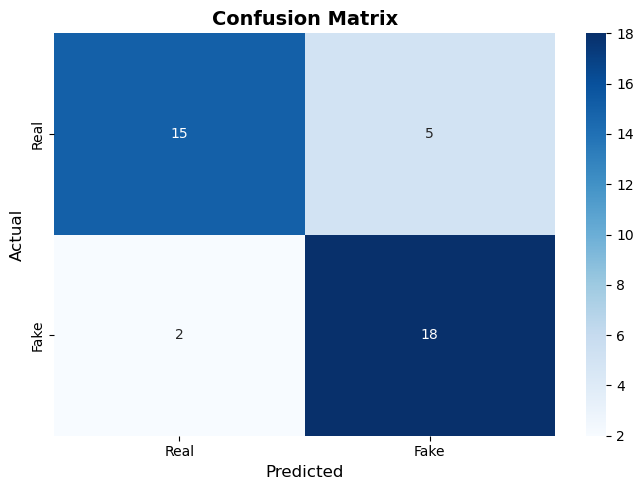

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 686ms/step - accuracy: 0.8250 - loss: 0.5376

Test Accuracy: 82.50%
Test Loss:     0.5376


In [44]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


y_pred_prob = model.predict(test_gen)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_gen.labels

# 2. Classification Report
print(classification_report(y_true, y_pred, target_names=['Real', 'Fake']))

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Test Accuracy
test_loss, test_acc = model.evaluate(test_gen)
print(f"\nTest Accuracy: {test_acc:.2%}")
print(f"Test Loss:     {test_loss:.4f}")

# CNN model

In [45]:

images, labels = next(iter(train_gen))
print("Image batch shape:", images.shape)
#  (32, 224, 224, 1)  (32, 224, 224, 3)

Image batch shape: (32, 224, 224, 3)


In [46]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Flatten, Dense, Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ========================
# 1. Data Augmentation
# ========================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,   
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)


train_gen = train_datagen.flow_from_dataframe(
    dataframe=data_train,
    directory=train_dir,
    x_col='image_name',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_gen = val_datagen.flow_from_dataframe(
    dataframe=data_train,
    directory=train_dir,
    x_col='image_name',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

test_gen = val_datagen.flow_from_dataframe(
    dataframe=data_test,
    directory=test_dir,
    x_col='image_name',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# ========================

# ========================
model2 = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same',
           input_shape=(224, 224, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.3),

    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

# ========================
# 3. Compile
# ========================
model2.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

# ========================
# 4. Callbacks
# ========================
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_cnn_signature.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# ========================
# 5. Training
# ========================
history = model2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,  
    callbacks=callbacks
)

# ========================
# 6. Evaluation
# ========================
results = model2.evaluate(val_gen)
print(f"\nVal Accuracy  : {results[1]:.4f}")
print(f"Val Precision : {results[2]:.4f}")
print(f"Val Recall    : {results[3]:.4f}")

Found 160 validated image filenames belonging to 2 classes.
Found 40 validated image filenames belonging to 2 classes.
Found 40 validated image filenames belonging to 2 classes.
Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5185 - loss: 0.9874 - precision: 0.5669 - recall: 0.5968  
Epoch 1: val_accuracy improved from None to 0.50000, saving model to best_cnn_signature.h5



Epoch 1: finished saving model to best_cnn_signature.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 33s 5s/step - accuracy: 0.5562 - loss: 0.9589 - precision: 0.5495 - recall: 0.6250 - val_accuracy: 0.5000 - val_loss: 0.6892 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6735 - loss: 0.8307 - precision: 0.6531 - recall: 0.7207 
Epoch 2: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 5s/step - accuracy: 0.6750 - loss: 0.8920 - precision: 0.6628 - recall: 0.7125 - val_accuracy: 0.5000 - val_loss: 0.6962 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6266 - loss: 0.9417 - precision: 0.6488 - recall: 0.6569 
Epoch 3: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - accuracy: 0.6250 - loss: 0.9158 - precision: 0.6190 - recall: 0.6500 - val_accuracy: 0.5000 - val_loss: 0.7064 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 4/5
5/5 ━━━━━━

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step
              precision    recall  f1-score   support

        Real       0.00      0.00      0.00        20
        Fake       0.50      1.00      0.67        20

    accuracy                           0.50        40
   macro avg       0.25      0.50      0.33        40
weighted avg       0.25      0.50      0.33        40



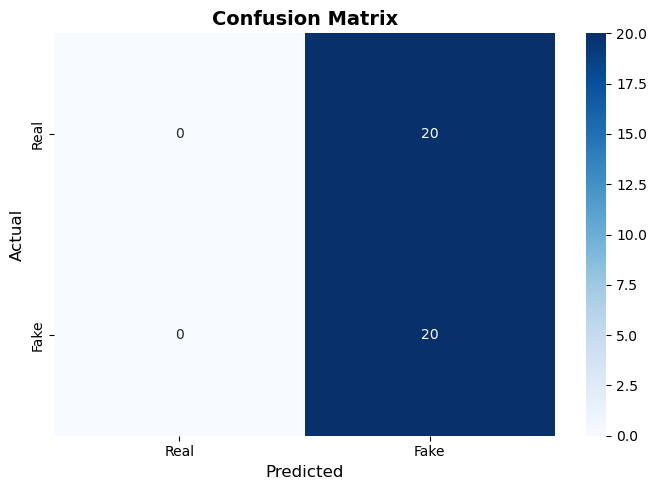

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.5000 - loss: 0.6918 - precision: 0.5000 - recall: 1.0000

Test Accuracy: 50.00%
Test Loss:     0.6918


In [49]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


y_pred_prob = model2.predict(test_gen)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_gen.labels

# 2. Classification Report
print(classification_report(y_true, y_pred, target_names=['Real', 'Fake']))

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Test Accuracy
test_loss, test_acc,*others = model2.evaluate(test_gen)
print(f"\nTest Accuracy: {test_acc:.2%}")
print(f"Test Loss:     {test_loss:.4f}")

In [53]:
model.save('best_model.keras')